First, we'll import the necessary PyTorch libraries. `torchvision` provides popular datasets, model architectures, and common image transformations.

First, we'll import the necessary PyTorch libraries. `torchvision` provides popular datasets, model architectures, and common image transformations.

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

Next, we'll define the transformations to apply to the images. CIFAR-10 images are 32x32 pixels. Common transformations include converting images to tensors and normalizing their pixel values.

In [ ]:
# Define transformations for the training and test sets
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

Now, let's download the CIFAR-10 dataset. PyTorch's `torchvision.datasets.CIFAR10` makes this straightforward. We'll download both the training and test splits.

In [ ]:
# Download and load the CIFAR-10 training dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

# Download and load the CIFAR-10 test dataset
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

print(f"Training set size: {len(trainset)}")
print(f"Test set size: {len(testset)}")

100%|██████████| 170M/170M [00:08<00:00, 19.1MB/s]


Training set size: 50000
Test set size: 10000


Finally, we'll create DataLoaders for both the training and testing datasets. DataLoaders help in iterating over the dataset in batches, shuffling data, and parallelizing data loading.

In [ ]:
# Define batch size
batch_size = 64

# Create DataLoaders
trainloader = DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

print("CIFAR-10 dataset loaded successfully!")
print(f"Number of training batches: {len(trainloader)}")
print(f"Number of test batches: {len(testloader)}")

CIFAR-10 dataset loaded successfully!
Number of training batches: 782
Number of test batches: 157


You can now iterate through `trainloader` and `testloader` in your deep learning model training loop.

Before visualizing, let's define the class names for CIFAR-10 so we can display them with the images.

In [ ]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"CIFAR-10 classes: {classes}")

CIFAR-10 classes: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


Now, let's grab a batch of training images and display them. We'll unnormalize the images before showing them, as they were normalized when loaded.

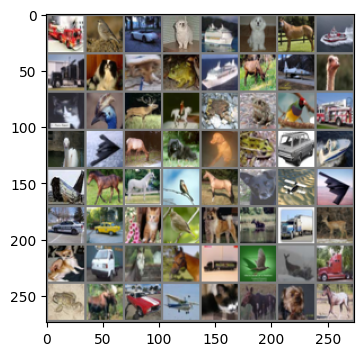

truck bird  car   dog   ship  dog   horse ship  truck dog   dog   frog  ship  deer  plane bird  cat   bird  deer  horse frog  frog  bird  truck bird  plane deer  dog   dog   frog  car   ship  plane horse horse bird  horse dog   plane plane car   car   cat   bird  dog   deer  truck deer  dog   truck horse horse truck bird  deer  truck frog  deer  car   plane cat   deer  dog   horse


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to unnormalize and show an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images
plt.figure(figsize=(10, 4))
imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(len(images))))
plt.show()


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Load pretrained ResNet18
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Modify the final layer for 10 CIFAR-10 classes
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 10)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet = resnet.to(device)

resnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
resnet.fc = nn.Linear(num_features, 10)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimiser (for ResNet first)
optimizer_resnet = optim.Adam(resnet.parameters(), lr=0.001)

# Training loop function
def train_model(model, optimizer, trainloader, testloader, epochs=5):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(trainloader):.4f}")

    print("Training complete.")


In [ ]:
train_model(resnet, optimizer_resnet, trainloader, testloader, epochs=5)

Epoch 1/5, Loss: 0.9542
Epoch 2/5, Loss: 0.6629
Epoch 3/5, Loss: 0.5259
Epoch 4/5, Loss: 0.4603
Epoch 5/5, Loss: 0.3468
Training complete.


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

def evaluate_model(model, testloader):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad(): # Disable gradient calculation
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

# Redefine resnet and device to ensure they are available for evaluation
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 10)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet = resnet.to(device)

resnet_accuracy = evaluate_model(resnet, testloader)
print(f'ResNet18 Accuracy on the test set: {resnet_accuracy:.2f}%')

ResNet18 Accuracy on the test set: 10.67%


In [ ]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

# Load pretrained ViT
vit = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)

# Replace final layer for CIFAR-10
num_features = vit.heads.head.in_features
vit.heads.head = nn.Linear(num_features, 10)

# Move to GPU
vit = vit.to(device)

vit


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 152MB/s]


VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a